In [6]:
import numpy as np
from scipy.spatial.transform import Rotation
m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
rng = np.random.default_rng(seed=42)
angles = (rng.random(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * rng.standard_normal((m, 3))  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

In [7]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
mnist = fetch_openml('mnist_784', as_frame=False)
x_train,x_test,y_train,y_test = mnist.data[:60000],mnist.data[60000:],mnist.target[:60000],mnist.target[60000:]
pca = PCA(n_components = 0.95)
X_reduced = pca.fit_transform(x_train)

In [8]:
pca.n_components_

np.int64(154)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline
clf = make_pipeline(PCA(random_state=42),
RandomForestClassifier(random_state=42))
param_distrib = {
"pca__n_components": np.arange(10, 80),
"randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
random_state=42)
rnd_search.fit(x_train[:1000], y_train[:1000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pca__n_components': array([10, 11... 78, 79]), 'randomforestclassifier__n_estimators': array([ 50, ...97, 498, 499])}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metr

In [11]:
print(rnd_search.best_params_)


{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


In [16]:
X_recovered = pca.inverse_transform(X_reduced)
import matplotlib.pyplot as plt

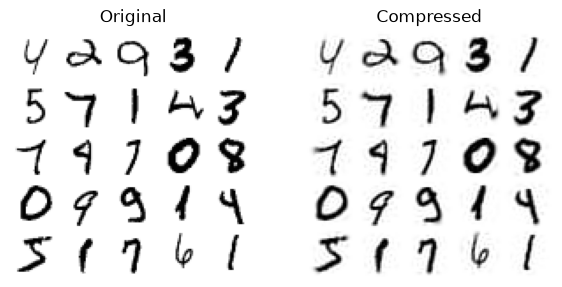

In [18]:
plt.figure(figsize=(7, 4))
for idx, X in enumerate((x_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

In [27]:
#Randomized pca
rnd_pca = PCA(154,svd_solver = "randomized",random_state = 42)
rnd_pca.fit_transform(x_train)
# without specifying the n_components and svd_solver as randomized do not do job of reduction

array([[ 123.93258864,  312.67426198,   24.51405174, ...,   62.00213296,
          -8.8147422 ,  -66.93993166],
       [1011.71837586,  294.85703831, -596.33956108, ...,   24.52514836,
          26.58534428,   16.99077095],
       [ -51.84960804, -392.17315289,  188.50974941, ...,    8.99144972,
          -2.99473092,   56.93622984],
       ...,
       [-178.0534496 , -160.0782111 ,  257.61308227, ...,  -35.30439525,
          -2.75142691,   23.97581712],
       [ 130.60607212,    5.59193632, -513.85867376, ...,   15.84132904,
         -18.38612585,   39.40742042],
       [-173.43595246,   24.71880228, -556.01889398, ...,  -29.62816702,
         -52.61652274,   27.99524134]], shape=(60000, 154))

In [33]:
#incremental  pca
from sklearn.decomposition import IncrementalPCA
n_batches = 100
inc_pca = IncrementalPCA(154)
for X_batch in np.array_split(x_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(x_train)

In [34]:
#for very large datasets greater than RAM available in device then we use memory mapping
filen = "my_mnist.mmap"
x_mmap = np.memmap(filen,dtype = 'float32',mode = 'write',shape=x_train.shape)
x_mmap[:] = x_train
x_mmap.flush


<bound method memmap.flush of memmap([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(60000, 784), dtype=float32)>

In [37]:
x_mmap = np.memmap(filen, dtype="float32").reshape(-1, 784)
batch_size = x_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.partial_fit(x_mmap)

,"n_components n_components: int, default=NoneNumber of components to keep. If ``n_components`` is ``None``,then ``n_components`` is set to ``min(n_samples, n_features)``.",154
,"batch_size batch_size: int, default=NoneThe number of samples to use for each batch. Only used when calling``fit``. If ``batch_size`` is ``None``, then ``batch_size``is inferred from the data and set to ``5 * n_features``, to provide abalance between approximation accuracy and memory consumption.",600
,"whiten whiten: bool, default=FalseWhen True (False by default) the ``components_`` vectors are dividedby ``n_samples`` times ``components_`` to ensure uncorrelated outputswith unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimesimprove the predictive accuracy of the downstream estimators bymaking data respect some hard-wired assumptions.",False
,"copy copy: bool, default=TrueIf False, X will be overwritten. ``copy=False`` can be used tosave memory but is unsafe for general use.",True
Name,Type,Value
"components_ components_: ndarray of shape (n_components, n_features)Principal axes in feature space, representing the directions ofmaximum variance in the data. Equivalently, the right singularvectors of the centered input data, parallel to its eigenvectors.The components are sorted by decreasing ``explained_variance_``.","ndarray[float32](154, 784)","[[ 0., 0., 0.,..., 0., 0., 0.], [ 0., 0., 0.,..., 0., 0., 0.], [ 0.,-0.,-0.,..., 0., 0., 0.], ..., [ 0., 0.,-0.,...,-0.,-0.,-0.], [ 0.,-0., 0.,..., 0., 0., 0.], [ 0., 0., 0.,..., 0., 0., 0.]]"
"explained_variance_ explained_variance_: ndarray of shape (n_components,)Variance explained by each of the selected components.","ndarray[float64](154,)","[332726.19,243286.57,211511.49,..., 1588.53, 1574.69, 1544.13]"
"explained_variance_ratio_ explained_variance_ratio_: ndarray of shape (n_components,)Percentage of variance explained by each of the selected components.If all components are stored, the sum of explained variances is equalto 1.0.","ndarray[float64](154,)","[0.1 ,0.07,0.06,...,0. ,0. ,0. ]"
"mean_ mean_: ndarray of shape (n_features,)Per-feature empirical mean, aggregate over calls to ``partial_fit``.","ndarray[float64](784,)","[0.,0.,0.,...,0.,0.,0.]"
n_components_ n_components_: intThe estimated number of components. Relevant when``n_components=None``.,int,154
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,784


In [45]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim
d = johnson_lindenstrauss_min_dim(5_000,eps = 0.1)
d

np.int64(7300)

In [46]:
n = 20_000
rng = np.random.default_rng(seed=42)
P = rng.standard_normal((d, n)) / np.sqrt(d)  # std dev = sqrt(variance)
X = rng.standard_normal((5_000, n))  # generate a fake dataset
X_reduced = X @ P.T